Testing how to get node count from skeleton data with Skan package

In [1]:
import numpy as np
from glob import glob
import os
import skimage as sk
from skan import draw
from skan.csr import skeleton_to_csgraph
from skan.csr import make_degree_image
from skan.csr import PathGraph
from skan import Skeleton, summarize
import napari
import matplotlib
matplotlib.rcParams["image.interpolation"] = 'none'
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import pandas as pd
from scipy.sparse import csr_array
from scipy.sparse.csgraph import connected_components

In [60]:
def get_measurements(masks, imgs, props, names):
    """
    Get measurements from masks and concatenate all dataframes into one.
    
    Args:
        masks: List of mask images
        imgs: List of image arrays
        names: List of image names
        props: Properties to measure
        pixel_size: Pixel size for spacing
    
    Returns:
        Single concatenated dataframe with all measurements
    """
    dfs = []
    for mask, img in zip(masks, imgs, names):
        df = sk.measure.regionprops_table(label_image=mask, intensity_image=img, properties=props, spacing=pixel_size)
        df = pd.DataFrame.from_dict(df)
        df['image_name'] = name[:-13]
        dfs.append(df)
    
    # Concatenate all dataframes into one
    merged_df = pd.concat(dfs, ignore_index=True)
    return merged_df

In [2]:
skeletons_files = sorted(glob(r"Image_Data\Oct_2025_300mm_exp\50_mM\Skeletons\*.tif"))
skeleton_names = list(map(os.path.basename,skeletons_files))

In [65]:
test_skellile_img = sk.io.imread(r'Image_Data\Oct_2025_300mm_exp\50_mM\Masked_cropped_images\29_Airyscan_Processing_pos10_z37_cropped_masked.tif')

In [66]:
viewer.add_image(test_skellile_img)

<Image layer 'test_skellile_img' at 0x24ed54009a0>

In [62]:
print(skeletons_files[0])

Image_Data\Oct_2025_300mm_exp\50_mM\Skeletons\29_Airyscan_Processing_pos10_z37_skeleton.tif


In [3]:
skellies = list(map(sk.io.imread,skeletons_files))

In [4]:
degree_images = [make_degree_image(img) for img in skellies]

In [5]:
nodes = [degree_image > 2 for degree_image in degree_images]

In [6]:
labeled_skellies = [sk.measure.label(skellie) for skellie in skellies]
labeled_nodes = [sk.measure.label(node) for node in nodes]

In [7]:
import random

In [12]:
i = random.randint(0,len(labeled_nodes))
print(i)

32


In [15]:
viewer = napari.view_labels(labeled_skellies[i], name="skellie labels")
viewer.add_image(degree_images[i],name='degree image')
viewer.add_labels(labeled_nodes[i],name='node labels')

E:\Temp\ipykernel_28860\2365082401.py:1: FutureWarning: `napari.view_labels` is deprecated and will be removed in napari 0.7.0.
Use `viewer = napari.Viewer(); viewer.add_labels(...)` instead.
  viewer = napari.view_labels(labeled_skellies[i], name="skellie labels")


<Labels layer 'node labels' at 0x253857319c0>

## Testing that connected components in scikit-imge and scipy assign labels in the same way
Want to make sure that the node data created with scikit-image can be combined with the skeleton dataframe based on the skeleton ID

In [14]:
#comparing scipy connected components
skellies_csgraph = csr_array(test_skellie)
#components, scipy_labels = connected_components(csgraph=skellies_csgraph,directed=False,return_labels=True)

In [21]:
bool_skellies = test_skellie/255

In [22]:
print(np.max(bool_skellies))

1.0


In [28]:
#comparing scipy connected components
test_skellie_data = summarize(Skeleton(test_skellie, spacing=1),separator="_")


In [51]:
one_skellie = test_skellie_data[test_skellie_data['skeleton_id'] == 15]

In [52]:
one_skellie.head()

,skeleton_id,node_id_src,node_id_dst,branch_distance,branch_type,mean_pixel_value,stdev_pixel_value,image_coord_src_0,image_coord_src_1,image_coord_dst_0,image_coord_dst_1,coord_src_0,coord_src_1,coord_dst_0,coord_dst_1,euclidean_distance
382,15,3705,4172,21.071068,1,255.0,0.0,303,412,322,409,303,412,322,409,19.235384
432,15,4172,4237,7.828427,2,255.0,0.0,322,409,325,403,322,409,325,403,6.708204
433,15,4172,4467,14.485281,1,255.0,0.0,322,409,334,415,322,409,334,415,13.416408
436,15,4235,4237,2.000000,1,255.0,0.0,325,401,325,403,325,401,325,403,2.000000
437,15,4237,4523,13.656854,1,255.0,0.0,325,403,337,401,325,403,337,401,12.165525


<Axes: >

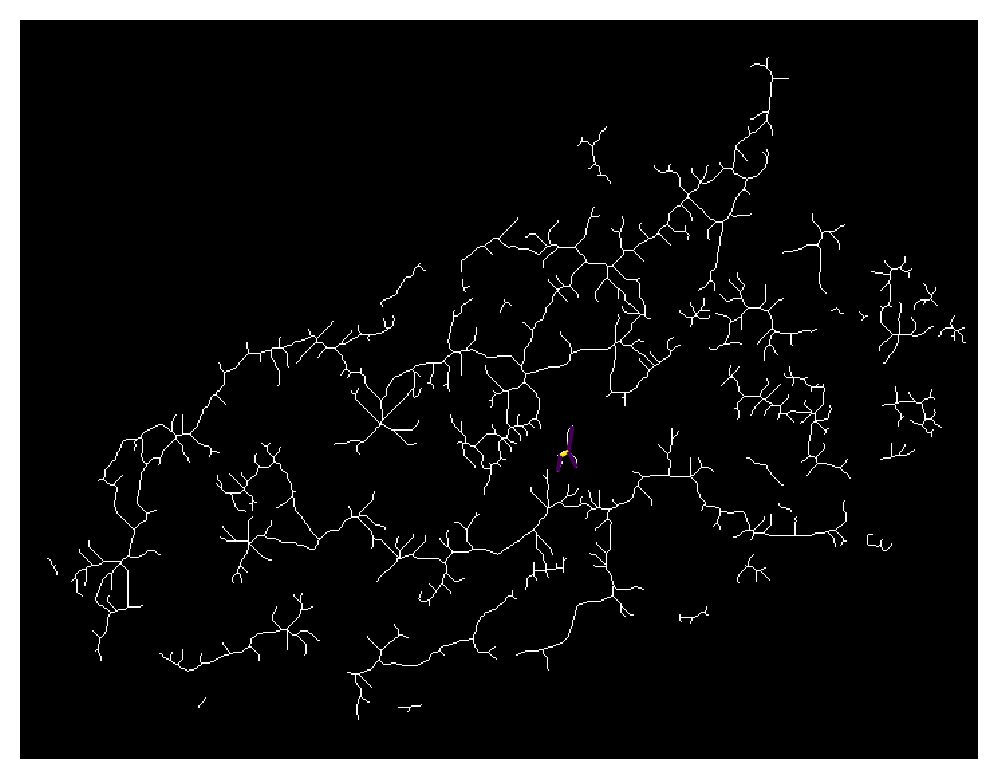

In [54]:
draw.overlay_euclidean_skeleton_2d(test_skellie,one_skellie)